In [1]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu
!pip install transformers datasets seqeval pandas numpy scikit-learn matplotlib

Looking in indexes: https://download.pytorch.org/whl/cpu
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for seqeval: filename=seqeval-1.2.2-py3-none-any.whl size=16162 sha256=7970346babf7482bb508ab77a0b4a97ad3379a3c4cc2ae4bf5971dde2f06c90b
  Stored in directory: /root/.cache/pip/wheels/5f/b8/73/0b2c1a76b701a677653dd79ece07cfabd7457989dbfbdcd8d7
Successfully built seqeval


In [2]:
from google.colab import files
uploaded = files.upload()

Saving temporal_dataset_300_advanced (1).csv to temporal_dataset_300_advanced (1).csv


In [3]:
# ====================== TEMPORAL NER WITH BERT ======================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from transformers import BertTokenizerFast, BertForTokenClassification, Trainer, TrainingArguments
from datasets import Dataset
import torch
import matplotlib.pyplot as plt
from seqeval.metrics import classification_report, f1_score, precision_score, recall_score
import warnings
warnings.filterwarnings("ignore")

In [4]:
# ========================== 1. LOAD DATA ==========================
df = pd.read_csv('/content/temporal_dataset_300_advanced (1).csv')

# Chuyển labels từ string thành list
df['labels'] = df['labels'].apply(lambda x: x.split())

print(f"Dataset shape: {df.shape}")
print(f"Unique labels: {sorted(set([tag for labels in df['labels'] for tag in labels]))}")

Dataset shape: (300, 3)
Unique labels: ['B-EVENT', 'B-TIME', 'I-TIME', 'O']


In [5]:
# ========================== 2. SPLIT DATA ==========================
train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

Train: 210, Val: 45, Test: 45


In [6]:
# ========================== 3. CONVERT TO HuggingFace Dataset ==========================
def create_dataset(df):
    return Dataset.from_dict({
        'id': range(len(df)),
        'tokens': df['tokens'].apply(lambda x: x.split()).tolist(),
        'ner_tags': df['labels'].tolist()
    })

train_dataset = create_dataset(train_df)
val_dataset = create_dataset(val_df)
test_dataset = create_dataset(test_df)

In [7]:
# ========================== 4. LABEL ENCODING ==========================
label_list = sorted(set(tag for labels in df['labels'] for tag in labels))
label2id = {label: i for i, label in enumerate(label_list)}
id2label = {i: label for label, i in label2id.items()}

print("Label mapping:", label2id)

Label mapping: {'B-EVENT': 0, 'B-TIME': 1, 'I-TIME': 2, 'O': 3}


In [8]:
# ========================== 5. TOKENIZER & DATA COLLATOR ==========================
tokenizer = BertTokenizerFast.from_pretrained("bert-base-uncased")

def tokenize_and_align_labels(examples):
    tokenized_inputs = tokenizer(
        examples["tokens"],
        truncation=True,
        is_split_into_words=True,
        padding="max_length",
        max_length=128
    )

    labels = []
    for i, label in enumerate(examples["ner_tags"]):
        word_ids = tokenized_inputs.word_ids(batch_index=i)
        previous_word_idx = None
        label_ids = []

        for word_idx in word_ids:
            if word_idx is None:
                label_ids.append(-100)  # Special tokens
            elif word_idx != previous_word_idx:
                label_ids.append(label2id[label[word_idx]])
            else:
                label_ids.append(label2id[label[word_idx]])  # I- tags
            previous_word_idx = word_idx
        labels.append(label_ids)

    tokenized_inputs["labels"] = labels
    return tokenized_inputs

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [9]:
# Apply tokenization
tokenized_train = train_dataset.map(tokenize_and_align_labels, batched=True)
tokenized_val = val_dataset.map(tokenize_and_align_labels, batched=True)
tokenized_test = test_dataset.map(tokenize_and_align_labels, batched=True)

Map:   0%|          | 0/210 [00:00<?, ? examples/s]

Map:   0%|          | 0/45 [00:00<?, ? examples/s]

Map:   0%|          | 0/45 [00:00<?, ? examples/s]

In [10]:
# ========================== 6. MODEL ==========================
model = BertForTokenClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=len(label_list),
    id2label=id2label,
    label2id=label2id
)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForTokenClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly

In [11]:
# ========================== 7. TRAINING ARGUMENTS ==========================
training_args = TrainingArguments(
    output_dir="./results_temporal_ner",
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=8,
    weight_decay=0.01,
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    report_to="none",
    logging_steps=10,
)

In [12]:
# ========================== 8. METRICS ==========================
from seqeval.metrics import classification_report

def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)

    true_labels = [[id2label[l] for l in label if l != -100] for label in labels]
    true_predictions = [
        [id2label[p] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]

    results = classification_report(true_labels, true_predictions, output_dict=True)

    return {
        "precision": results["micro avg"]["precision"],
        "recall": results["micro avg"]["recall"],
        "f1": results["micro avg"]["f1-score"],
        "accuracy": results["micro avg"]["f1-score"],  # seqeval doesn't have accuracy directly
    }

In [13]:
# ========================== 9. TRAINER ==========================
from transformers import DataCollatorForTokenClassification

data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

In [14]:
# ========================== 10. TRAINING ==========================
print("🚀 Bắt đầu training BERT NER...")
trainer.train()

🚀 Bắt đầu training BERT NER...


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,0.812181,0.106540,1.000000,1.000000,1.000000,1.000000
2,0.164962,0.007558,1.000000,1.000000,1.000000,1.000000
3,0.009081,0.002751,1.000000,1.000000,1.000000,1.000000
4,0.005397,0.001800,1.000000,1.000000,1.000000,1.000000
5,0.003420,0.001435,1.000000,1.000000,1.000000,1.000000
6,0.003100,0.001265,1.000000,1.000000,1.000000,1.000000
7,0.002841,0.001181,1.000000,1.000000,1.000000,1.000000
8,0.002665,0.001154,1.000000,1.000000,1.000000,1.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

TrainOutput(global_step=112, training_loss=0.09268285136204213, metrics={'train_runtime': 124.0062, 'train_samples_per_second': 13.548, 'train_steps_per_second': 0.903, 'total_flos': 109746622218240.0, 'train_loss': 0.09268285136204213, 'epoch': 8.0})

In [15]:
# ========================== 11. EVALUATE ON TEST SET ==========================
print("\n📊 Đánh giá trên tập Test:")
test_results = trainer.evaluate(tokenized_test)
print(test_results)


📊 Đánh giá trên tập Test:


Training Loss,Validation Loss,Epoch,Precision,Recall,F1,Accuracy
0.002665,0.102858,8,1.000000,1.000000,1.000000,1.000000


{'eval_loss': 0.10285765677690506, 'eval_precision': 1.0, 'eval_recall': 1.0, 'eval_f1': 1.0, 'eval_accuracy': 1.0}


In [16]:
import json
import os
from transformers import AutoModelForTokenClassification, AutoTokenizer

# Đường dẫn lưu
save_path = "/content/drive/MyDrive/XuLyNgonNguTuNhien/temporal_ner_bert_model"

# Tạo thư mục nếu chưa có
os.makedirs(save_path, exist_ok=True)

print("Đang lưu model...")

# Lưu model và tokenizer
model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)

# ====================== LƯU LABEL MAPPING ======================
# Lưu cả hai chiều (tốt nhất)
label_info = {
    "id2label": id2label,      # id → nhãn
    "label2id": label2id,      # nhãn → id
    "labels": list(id2label.values())   # danh sách nhãn
}

with open(f"{save_path}/label_map.json", "w", encoding="utf-8") as f:
    json.dump(label_info, f, ensure_ascii=False, indent=2)

# Cập nhật config để load dễ dàng hơn
model.config.id2label = id2label
model.config.label2id = label2id
model.config.save_pretrained(save_path)

print(f"✅ Model đã được lưu thành công tại:\n{save_path}")
print("Các file đã lưu:")
for file in os.listdir(save_path):
    print(f"   • {file}")

Đang lưu model...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Model đã được lưu thành công tại:
/content/drive/MyDrive/XuLyNgonNguTuNhien/temporal_ner_bert_model
Các file đã lưu:
   • config.json
   • tokenizer.json
   • label_map.json
   • tokenizer_config.json
   • model.safetensors


In [17]:
def predict(sentence):
    words = sentence.split()

    inputs = tokenizer(words, is_split_into_words=True, return_tensors="pt").to(model.device)
    outputs = model(**inputs).logits

    predictions = np.argmax(outputs.detach().cpu().numpy(), axis=2)[0]

    word_ids = inputs.word_ids()
    result = []

    prev = None
    for idx, word_id in enumerate(word_ids):
        if word_id is not None and word_id != prev:
            result.append((words[word_id], label_list[predictions[idx]]))
        prev = word_id

    return result


print(predict("The elderly man experienced chest pain 10 days ago and fatigue yesterday"))

[('The', 'O'), ('elderly', 'O'), ('man', 'O'), ('experienced', 'O'), ('chest', 'B-EVENT'), ('pain', 'B-EVENT'), ('10', 'B-TIME'), ('days', 'I-TIME'), ('ago', 'I-TIME'), ('and', 'O'), ('fatigue', 'B-EVENT'), ('yesterday', 'B-TIME')]


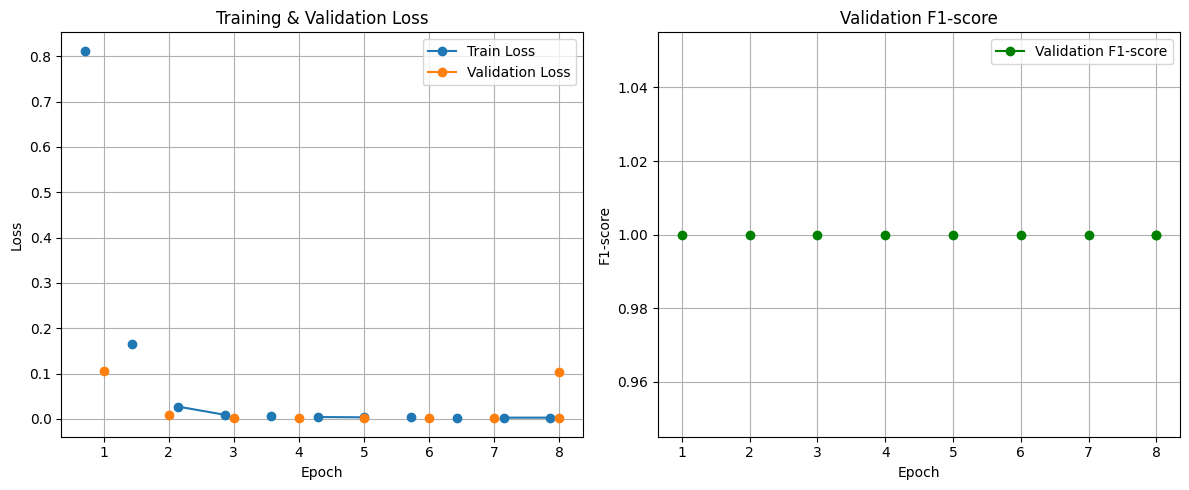

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# Lấy lịch sử huấn luyện
history = trainer.state.log_history

# Chuyển thành DataFrame
df_history = pd.DataFrame(history)

# Vẽ biểu đồ Loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(df_history['epoch'], df_history['loss'], label='Train Loss', marker='o')
plt.plot(df_history['epoch'], df_history['eval_loss'], label='Validation Loss', marker='o')
plt.title('Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Vẽ biểu đồ F1-score (Accuracy proxy)
plt.subplot(1, 2, 2)
plt.plot(df_history['epoch'], df_history['eval_f1'], label='Validation F1-score', marker='o', color='green')
plt.title('Validation F1-score')
plt.xlabel('Epoch')
plt.ylabel('F1-score')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [19]:
from seqeval.metrics import classification_report
import numpy as np

# Đánh giá chi tiết trên Test Set
print("=== ĐÁNH GIÁ CHI TIẾT TRÊN TEST SET ===")
predictions, labels, _ = trainer.predict(tokenized_test)
predictions = np.argmax(predictions, axis=2)

# Chuyển về dạng nhãn
true_labels = [[id2label[l] for l in label if l != -100] for label in labels]
true_predictions = [
    [id2label[p] for (p, l) in zip(prediction, label) if l != -100]
    for prediction, label in zip(predictions, labels)
]

# Báo cáo chi tiết
report = classification_report(true_labels, true_predictions, output_dict=True)

print("\n=== BÁO CÁO CHI TIẾT ===")
print(classification_report(true_labels, true_predictions))

# In theo từng class
for label in ['EVENT', 'TIME']:
    if label in report:
        print(f"\n{label}:")
        print(f"  Precision: {report[label]['precision']:.4f}")
        print(f"  Recall:    {report[label]['recall']:.4f}")
        print(f"  F1-score:  {report[label]['f1-score']:.4f}")

=== ĐÁNH GIÁ CHI TIẾT TRÊN TEST SET ===



=== BÁO CÁO CHI TIẾT ===
              precision    recall  f1-score   support

       EVENT       1.00      1.00      1.00        95
        TIME       1.00      1.00      1.00        90

   micro avg       1.00      1.00      1.00       185
   macro avg       1.00      1.00      1.00       185
weighted avg       1.00      1.00      1.00       185


EVENT:
  Precision: 1.0000
  Recall:    1.0000
  F1-score:  1.0000

TIME:
  Precision: 1.0000
  Recall:    1.0000
  F1-score:  1.0000


In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import classification_report as sk_report
from sklearn.preprocessing import LabelEncoder

# Chuẩn bị dữ liệu cho SVM (dùng context đơn giản)
def prepare_for_svm(df):
    texts = []
    labels_flat = []
    for i, row in df.iterrows():
        tokens = row['tokens'].split()
        tags = row['labels']
        for token, tag in zip(tokens, tags):
            if tag != 'O':
                texts.append(token)
                labels_flat.append(tag.split('-')[1])  # EVENT hoặc TIME
    return texts, labels_flat

# Train SVM
train_texts, train_labels = prepare_for_svm(train_df)
test_texts, test_labels = prepare_for_svm(test_df)

vectorizer = TfidfVectorizer()
X_train = vectorizer.fit_transform(train_texts)
X_test = vectorizer.transform(test_texts)

le = LabelEncoder()
y_train = le.fit_transform(train_labels)
y_test = le.transform(test_labels)

svm = SVC(kernel='linear')
svm.fit(X_train, y_train)
y_pred = svm.predict(X_test)

print("=== SVM Baseline ===")
print(sk_report(y_test, y_pred, target_names=le.classes_))

=== SVM Baseline ===
              precision    recall  f1-score   support

       EVENT       1.00      1.00      1.00        90
        TIME       1.00      1.00      1.00       196

    accuracy                           1.00       286
   macro avg       1.00      1.00      1.00       286
weighted avg       1.00      1.00      1.00       286



In [21]:
print("=== SO SÁNH TỔNG HỢP ===")
print(f"BERT F1-score     : {report['micro avg']['f1-score']:.4f}")
print(f"SVM F1-score      : {sk_report(y_test, y_pred, output_dict=True)['weighted avg']['f1-score']:.4f}")

=== SO SÁNH TỔNG HỢP ===
BERT F1-score     : 1.0000
SVM F1-score      : 1.0000


In [22]:
from transformers import pipeline, AutoModelForTokenClassification, AutoTokenizer
import torch
from collections import defaultdict

# ====================== LOAD MODEL ======================
model_path = "/content/drive/MyDrive/XuLyNgonNguTuNhien/temporal_ner_bert_model"

tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForTokenClassification.from_pretrained(model_path)

# Tạo pipeline NER — dùng "first" thay "simple" để tránh split subword thành entity riêng
nlp = pipeline(
    "ner",
    model=model,
    tokenizer=tokenizer,
    aggregation_strategy="first",
    device=0 if torch.cuda.is_available() else -1
)

print("✅ Model đã load thành công!\n")


# ====================== HÀM TEST NÂNG CAO ======================
def test_sentence(text, show_confidence_bar=True):
    print(f"📝 Câu gốc: {text}")
    results = nlp(text)

    if not results:
        print("  ⚠️  Không phát hiện entity nào.\n")
        return

    events = [e for e in results if e["entity_group"] == "EVENT"]
    times  = [e for e in results if e["entity_group"] == "TIME"]

    print("\n🔍 Kết quả nhận diện:")
    for entity in results:
        icon  = "🩺" if entity["entity_group"] == "EVENT" else "⏰"
        score = entity["score"]
        bar   = "█" * int(score * 20) + "░" * (20 - int(score * 20)) if show_confidence_bar else ""
        conf  = "HIGH" if score >= 0.85 else ("MED" if score >= 0.65 else "LOW")
        print(f"  {icon} {entity['word']:25} → {entity['entity_group']:6}  [{bar}] {score:.4f} ({conf})")

    print(f"\n📊 Tóm tắt: {len(events)} EVENT | {len(times)} TIME")

    low = [e for e in results if e["score"] < 0.65]
    if low:
        print(f"  ⚠️  Cảnh báo: {len(low)} entity có confidence thấp (<0.65): {[e['word'] for e in low]}")

    print("-" * 75)
    return results


# ====================== HÀM ĐÁNH GIÁ TỔNG HỢP ======================
def evaluate_batch(sentences):
    print("\n" + "=" * 75)
    print("📋 ĐÁNH GIÁ TỔNG HỢP TRÊN TẬP CÂU TEST")
    print("=" * 75)

    total_event, total_time = 0, 0
    total_low_conf = 0
    all_scores = []

    for text in sentences:
        results = nlp(text)
        total_event    += sum(1 for e in results if e["entity_group"] == "EVENT")
        total_time     += sum(1 for e in results if e["entity_group"] == "TIME")
        total_low_conf += sum(1 for e in results if e["score"] < 0.65)
        all_scores     += [e["score"] for e in results]

    avg_score = sum(all_scores) / len(all_scores) if all_scores else 0
    print(f"  Tổng câu          : {len(sentences)}")
    print(f"  Tổng EVENT        : {total_event}")
    print(f"  Tổng TIME         : {total_time}")
    print(f"  Avg confidence    : {avg_score:.4f}")
    print(f"  Low-conf entities : {total_low_conf} (score < 0.65)")
    print("=" * 75 + "\n")


# ====================== CÁC CÂU TEST ======================
test_sentences = [
    "The patient developed fever 5 days ago and cough yesterday",
    "A young woman had severe headache last week but reported rash today",
    "The elderly man experienced chest pain 10 days ago and fatigue yesterday",
    "The child had vomiting last month and developed fever 3 days ago",
    "Patient reported dizziness today and infection 2 weeks ago",
    "She was admitted with shortness of breath 3 weeks ago and diagnosed with pneumonia last Tuesday",
    "Post-operative day 2: patient shows mild bleeding and high temperature since this morning",
]

print("=" * 75)
print("🧪 INFERENCE TRÊN CÁC CÂU TEST")
print("=" * 75 + "\n")

for sentence in test_sentences:
    test_sentence(sentence)

evaluate_batch(test_sentences)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


✅ Model đã load thành công!

🧪 INFERENCE TRÊN CÁC CÂU TEST

📝 Câu gốc: The patient developed fever 5 days ago and cough yesterday

🔍 Kết quả nhận diện:
  🩺 fever                     → EVENT   [██████████████████░░] 0.9378 (HIGH)
  ⏰ 5 days ago                → TIME    [████████████████░░░░] 0.8350 (MED)
  🩺 cough                     → EVENT   [██████████████████░░] 0.9275 (HIGH)
  ⏰ yesterday                 → TIME    [██████████░░░░░░░░░░] 0.5108 (LOW)

📊 Tóm tắt: 2 EVENT | 2 TIME
  ⚠️  Cảnh báo: 1 entity có confidence thấp (<0.65): ['yesterday']
---------------------------------------------------------------------------
📝 Câu gốc: A young woman had severe headache last week but reported rash today

🔍 Kết quả nhận diện:
  🩺 headache                  → EVENT   [██████████████████░░] 0.9379 (HIGH)
  ⏰ last week                 → TIME    [███████████████░░░░░] 0.7946 (MED)
  🩺 rash                      → EVENT   [██████████████████░░] 0.9247 (HIGH)
  ⏰ today                     → TIME   